In [2]:
import polars as pl
import ast
from procompa import get_project_root
PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [3]:
#get  relevant complexes (eitehr no sufficnent7 no homology match compared to pdb) and filter for complexes with more than 2 proteins
pdb_mapping = pl.read_csv(data_dir/ "complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv")
pdb_mapping_intresting = pdb_mapping.filter(pl.col("match_class").is_in(["no_homology_match", "no_sufficient_match"]))
pdb_mapping_intresting_big = pdb_mapping_intresting.filter(pl.col("n_proteins") > 2)

In [4]:
all_cf_output = pl.read_csv(data_dir / "Pipeline/10_all_CP_complexes/all_pdb_present_10_all_CP_complexes_pool_pipeline_complexes_combfold_results.csv") #only 613 instead of 634, cause pipeline cant handle some identifiers yet

In [5]:
intresting_no_struc_complexes = all_cf_output.filter(pl.col("complex_ac").is_in(pdb_mapping_intresting_big["complex_ac"].implode()))

In [6]:
# get max cf confidence for each run
shared = ["complex_ac", "identifiers", "correct_pred_count", "correct_pred_rank", "n_pairs_used", "pairs_used"]

frames = [
    intresting_no_struc_complexes.select(
        *shared,
        pl.lit(i).alias("pred_rank"),
        pl.col(f"pred_{i}").alias("pred_stoic"),
        pl.col(f"CF_{i}_n_assemblies").alias("n_assemblies"),
        pl.col(f"CF_{i}_confidence").alias("CF_confidence"),
        pl.col(f"CF_{i}_reason").alias("CF_reason"),
    )
    for i in [1, 2, 3]
]

# true stoichiometry as pred_rank=0
frames.append(
    intresting_no_struc_complexes.select(
        *shared,
        pl.lit(0).alias("pred_rank"),
        pl.lit(None).cast(pl.String).alias("pred_stoic"),
        pl.col("CF_true_n_assemblies").alias("n_assemblies"),
        pl.col("CF_true_confidence").alias("CF_confidence"),
        pl.col("CF_true_reason").alias("CF_reason"),
    )
)

long_intresting_no_struc_complexes = (
    pl.concat(frames)
    .sort("complex_ac", "pred_rank")
    .filter(
        (pl.col("pred_rank") != 0) |
        (pl.col("correct_pred_rank") == "none")
    )
    .with_columns(
        pl.col("CF_confidence")
        .map_elements(
            lambda s: max(ast.literal_eval(s).values()) if s not in (None, "{}") else None,
            return_dtype=pl.Float64,
        )
        .alias("CF_confidence_max")
    )
)

In [7]:
#best CF for each run (so that stoichiometry)
long_intresting_no_struc_complexes = long_intresting_no_struc_complexes.with_columns(
    pl.col("CF_confidence")
    .map_elements(
        lambda s: max(ast.literal_eval(s).values()) if s not in (None, "{}") else None,
        return_dtype=pl.Float64,
    )
    .alias("CF_confidence_max")
)

In [8]:
#for when stoic didnt get it, is the correct one (added) better CF confidence?, is the value whete stoic pred is missing higerher than the one from either of the stoic runs
complex_summary = (
    long_intresting_no_struc_complexes
    .group_by("complex_ac")
    .agg(
        pl.col("correct_pred_rank").first(),
        pl.col("pred_rank")
            .filter(pl.col("CF_confidence_max") == pl.col("CF_confidence_max").max())
            .first()
            .alias("best_pred_rank"),
        pl.col("CF_confidence_max").max().alias("max_CF_confidence"),
    )
    .with_columns(
        (pl.col("best_pred_rank") == 0).alias("best_from_added_stoic")
    )
)

In [9]:
# add whether the complex has no homology macth or just infufficient
complex_summary = complex_summary.join(pdb_mapping_intresting_big, on="complex_ac", how="left")


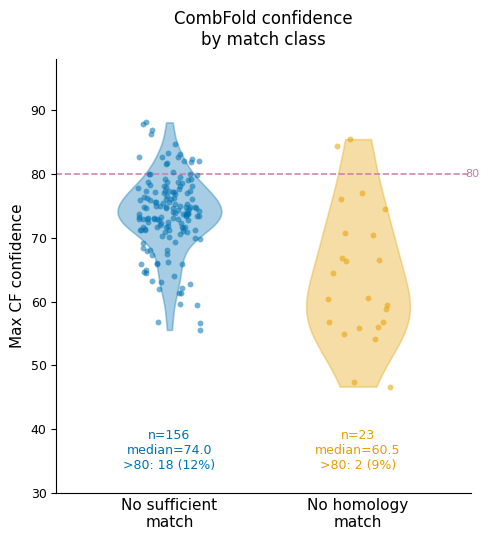

In [ ]:
# %%
THRESHOLD = 80
C_SUFF = '#0072B2'
C_HOMO = '#E69F00'

order = ['no_sufficient_match', 'no_homology_match']
label_map = {
    'no_sufficient_match': 'No sufficient\nmatch',
    'no_homology_match':   'No homology\nmatch',
}
color_map = {
    'no_sufficient_match': C_SUFF,
    'no_homology_match':   C_HOMO,
}

groups = {
    cls: (
        complex_summary
        .filter(pl.col("match_class") == cls)
        .filter(pl.col("max_CF_confidence").is_not_null())
        ["max_CF_confidence"]
        .to_numpy()
    )
    for cls in order
}

a, b = groups['no_sufficient_match'], groups['no_homology_match']
_, p = stats.mannwhitneyu(a, b, alternative='two-sided')

fig, ax = plt.subplots(figsize=(5, 5.5))

# Violin
vp = ax.violinplot(
    [groups[cls] for cls in order],
    positions=[0, 1],
    widths=0.55,
    showmedians=False,
    showextrema=False,
)
for body, cls in zip(vp['bodies'], order):
    body.set_facecolor(color_map[cls])
    body.set_alpha(0.35)
    body.set_edgecolor(color_map[cls])
    body.set_linewidth(1.2)

# Jittered strip
rng = np.random.default_rng(42)
for i, cls in enumerate(order):
    vals = groups[cls]
    jitter = rng.uniform(-0.17, 0.17, size=len(vals))
    ax.scatter(i + jitter, vals, color=color_map[cls], s=18, alpha=0.55, linewidths=0, zorder=2)

# Threshold line
ax.axhline(THRESHOLD, color='#CC79A7', linestyle='--', linewidth=1.2, alpha=0.9, zorder=1)
ax.text(1.57, THRESHOLD, str(THRESHOLD), color='#CC79A7', va='center', ha='left', fontsize=8)

# Per-group annotation: n, median, >80
for i, cls in enumerate(order):
    vals = groups[cls]
    n_above = (vals > THRESHOLD).sum()
    ax.text(
        i, 40,
        f'n={len(vals)}\nmedian={np.median(vals):.1f}\n>{THRESHOLD}: {n_above} ({100 * n_above / len(vals):.0f}%)',
        ha='center', va='top', fontsize=9, color=color_map[cls],
    )

# p-value bracket
# y_top = max(a.max(), b.max()) + 3
# ax.plot([0, 0, 1, 1], [y_top, y_top + 1.5, y_top + 1.5, y_top], color='#333333', lw=1.2)
# p_str = 'p < 0.0001' if p < 1e-4 else f'p = {p:.4f}'
# ax.text(0.5, y_top + 2, p_str, ha='center', va='bottom', fontsize=9.5, color='#333333')

ax.set_xticks([0, 1])
ax.set_xticklabels([label_map[c] for c in order], fontsize=11)
ax.set_ylabel('Max CF confidence', fontsize=11)
ax.set_title('CombFold confidence\nby match class', fontsize=12, pad=10)
ax.set_xlim(-0.6, 1.6)
#ax.set_ylim(30, y_top + 7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
